In [1]:
import re
import unidecode
import string
import random

import torch
import torch.nn as nn
from torch.autograd import Variable

## Scarichiamo il nostro dataset

In [2]:
all_characters = string.printable
n_characters = len(all_characters)

text = unidecode.unidecode(open("content/alice.txt", 'rb').read().decode(encoding='utf-8'))
text_len = len(text)
print('text_len =', text_len)


text_len = 148574


In [3]:
def random_chunk(text, chunk_len = 200):
    start_index = random.randint(0, text_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return text[start_index:end_index]

print(random_chunk(text))


of long ago:  and how she would feel with all their
simple sorrows, and find a pleasure in all their simple joys,
remembering her own child-life, and the happy summer days.

                           


In [4]:
vocab = sorted(set(text))
print(f'{len(vocab)} unique characters')

72 unique characters


In [5]:
# class GRU(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size, n_layers=1):
#         super(GRU, self).__init__()
#         self.input_size = input_size
#         self.hidden_size = hidden_size
#         self.output_size = output_size
#         self.n_layers = n_layers

#         self.encoder = nn.Embedding(input_size, hidden_size)
#         self.gru = nn.GRU(hidden_size, hidden_size, n_layers)
#         self.decoder = nn.Linear(hidden_size, output_size)

#     def forward(self, input, hidden):
#         input = self.encoder(input.view(1, -1))
#         output, hidden = self.gru(input.view(1, 1, -1), hidden)
#         output = self.decoder(output.view(1, -1))
#         return output, hidden

#     def init_hidden(self):
#         return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))


In [6]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=2):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        self.encoder = nn.Embedding(input_size, hidden_size)
        self.LSTM = nn.LSTM(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden):
        embedded = self.encoder(input.view(1, -1)) #flattening
        output, (hidden_state, cell_state) = self.LSTM(embedded.view(1, 1, -1), hidden) #computes lstm memory
        output = self.decoder(output.view(1, -1)) #predicts tokens
        return output, (hidden_state, cell_state)

    def init_hidden(self):
        return (
            torch.zeros(self.n_layers, 1, self.hidden_size),
            torch.zeros(self.n_layers, 1, self.hidden_size)
                )

In [7]:
from torchsummary import summary

In [8]:
def char_tensor(string):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = all_characters.index(string[c])
    return Variable(tensor)

print(char_tensor('abcDEF'))


tensor([10, 11, 12, 39, 40, 41])


In [9]:
def random_training_set(text):
    chunk = random_chunk(text)
    inp = char_tensor(chunk[:-1])
    target = char_tensor(chunk[1:])
    return inp, target


# Training function

In [10]:
def train(inp, target):
    hidden = decoder.init_hidden()
    decoder.zero_grad()
    loss = 0

    for c in range(len(inp)):
        output, hidden = decoder(inp[c], hidden)
        loss += criterion(output, target[c].view(-1))

    loss.backward()
    decoder_optimizer.step()

    return loss.item() / len(inp)


## Evaluation function

In [11]:
def evaluate(prime_str='A', predict_len=100, temperature=0.8):
    hidden = decoder.init_hidden()
    prime_input = char_tensor(prime_str)
    predicted = prime_str

    # Use priming string to "build up" hidden state
    for p in range(len(prime_str) - 1):
        _, hidden = decoder(prime_input[p], hidden)
    inp = prime_input[-1]

    for p in range(predict_len):
        output, hidden = decoder(inp, hidden)

        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]

        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        inp = char_tensor(predicted_char)

    return predicted


In [13]:
n_epochs = 2000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 2
lr = 0.005

decoder = LSTM(n_characters, hidden_size, n_characters, n_layers)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    inp, target = random_training_set(text)
    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('[(%d %d%%) %.4f]' % (epoch, epoch / n_epochs * 100, loss))
        print(evaluate('Wh', 100), '\n')

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


[(100 5%) 2.8929]
Whe achin, acir te' `the -Ohat acranser peos tinl' al soa pif aln?oleys qad! th oy ate dind se sa hre
 

[(200 10%) 2.6201]
Whe mhe tallsy' suind in goew to his bithor cur!t at to whor the be and rit rorg Dor wife, caghe Alind 

[(300 15%) 2.2584]
Whe `heas thind as has it to noryy ting it ow any ou, taid ing to in thy
wough a dory waigitle on inti 

[(400 20%) 2.2464]
Whe she Iing gut in
tay the gang wike sure alid
hing she the as she shat she now the gor a, what wand  

[(500 25%) 2.0326]
What her hing the pous ought the dar haid bees the parding harginkelf, whe caty beand sore her, `as he 

[(600 30%) 1.9890]
Whe wong the Kind and sas in that thout
don thound me timple the donn me gret she for she wand foll on 

[(700 35%) 1.9299]
Whing lownly!' seought it was rept wIited for.t look, and she Weres that Alice the
cean, don't cookin' 

[(800 40%) 1.7374]
Whith; wrattle and necespooked and and in and they again tratuched the the
creak it her or fell wathed 

[(900 45%

# Plotting the loss

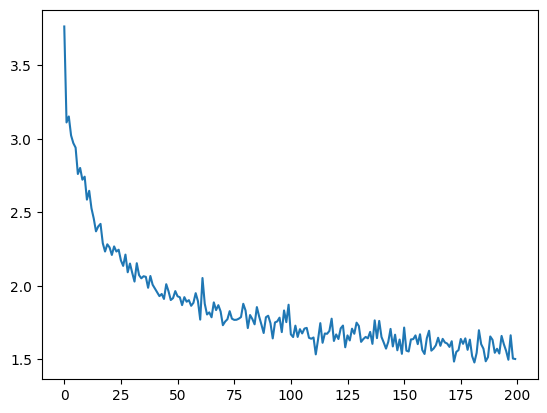

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

# Evaluating the results

In [15]:
print(evaluate('Th', 200, temperature=0.8))

The neyes isked the Hatter.'

  `It bleary fite a little many in askeing to ferly sit--and the dron't!' the Nout her very great pleater off.  Alice real the serpent the risten,' said Alice they marked, 


In [16]:
print(evaluate('Th', 200, temperature=1.4))

The peezy `Of
shouyhadly mais.  Ah?' lalk! weral don't ratchiver!' saider;'
stlis:  freet sippy.

   *       *  went
roned,' and
beiscrelye, be
thing.

  andy discked into dibfy,' sAicurring reetice. *`


In [20]:
print(evaluate('Th', 200, temperature=0.6))

The house,' said the ot who them her were as was fertrering to they was off the Mit with the Mock Turtle peging.

  `Pover very did her hand, thinked to they had the of the wort sore sore.

  As a sort,
